In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import scipy.stats as stats
from copy import deepcopy

from pickagm.distributions import gcim_distributions, gcim_simulation

from pickagm.corrmodels import (
    CORR_MODELS
)


from openquake.hazardlib.imt import PGA, SA, RSD595, Sa_avg2, AvgSA
from openquake.hazardlib.gsim.mgmpe.generic_gmpe_avgsa import GenericGmpeAvgSA
from openquake.hazardlib.gsim.bahrampouri_2021_duration import (
    BahrampouriEtAldm2021Asc,
    BahrampouriEtAldm2021SInter,
    BahrampouriEtAldm2021SSlab
)

from phd_project.config.config import load_config 
from phd_project.scripts.oqhelpers import parse_nrml_logic_tree
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    ESHM20SiteRupCtxBuilder,
    SA_PGA_gmm_from_logic_tree,
    AvgSA_gmm_from_logic_tree
)

cfg = load_config()

In [3]:
# Load the disaggregation data
fp = cfg["proc_data"]["site_hazard_disaggregation"] / "AvgSA_03_disagg_data_60sites_5poes.pickle"
with open(fp, "rb") as f:
    disagg_data_AvgSA_03 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard_disaggregation"] / "AvgSA_03_disagg_stats_60sites_5poes.pickle"
with open(fp, "rb") as f:
    disagg_stats_AvgSA_03 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard_disaggregation"] / "AvgSA_06_disagg_data_60sites_5poes.pickle"
with open(fp, "rb") as f:
    disagg_data_AvgSA_06 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard_disaggregation"] / "AvgSA_06_disagg_stats_60sites_5poes.pickle"
with open(fp, "rb") as f:
    disagg_stats_AvgSA_06 = pickle.load(f)

# load the site file
sites = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])

# load the flatfiles
flatfile_folder = cfg["proc_data"]["corr_model"] / "reverse" / "flatfiles"
flatfiles = {}
for f in [f for f in os.listdir(flatfile_folder) if f.endswith(".csv")]:
    tag = f.split("_")[0]
    flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0)

flatfiles["volcanic"] = pd.read_csv(cfg["raw_data"]["gm_flatfiles"] / "volcanic_lanzanoluzi_flatfile.csv", 
                                    delimiter=";", index_col=0)


C:\Users\clemettn\AppData\Local\Temp\ipykernel_38956\3603788871.py:26: DtypeWarning: Columns (18,20,21,34,38,39,48,50) have mixed types. Specify dtype option on import or set low_memory=False.
  flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0)


# AvgSA([0, 3])

In [4]:
# set some parameters for the selection
sa_periods = np.round(np.geomspace(0.025, 8, num=30), 3)
nonSA_imts = [AvgSA([0,3]).string, RSD595().string, PGA().string]  # strings match the correlation matrix
cond_imt = AvgSA([0,3])  # strings match the correlation matrix
selection_imts = [RSD595(), PGA()] + [SA(period) for period in sa_periods]  # these need to be imt instances to work with GMMs

# Create the GMM Map for AvgSA by reading the logic tree
fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to3_median_branch.xml"
GMM_AvgSA_LT = parse_nrml_logic_tree(file_path=fp)

GMM_MAP = {
    "Craton": {
        "AvgSA": AvgSA_gmm_from_logic_tree(GMM_AvgSA_LT, "Craton"),         # these strings need to match the imt.name so that they be found when the imt is up to be calculated.
        "PGA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Craton"),
        "SA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Craton"),
        "RSD595": BahrampouriEtAldm2021Asc(),
        },
    "Non-Subduction Deep": {
        "AvgSA": AvgSA_gmm_from_logic_tree(GMM_AvgSA_LT, "Non-Subduction Deep"),
        "PGA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Non-Subduction Deep"),
        "SA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Non-Subduction Deep"),
        "RSD595": BahrampouriEtAldm2021SSlab()
        },
    "Shallow Default": {
        "AvgSA": AvgSA_gmm_from_logic_tree(GMM_AvgSA_LT, "Shallow Default"),
        "PGA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Shallow Default"),
        "SA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Shallow Default"),
        "RSD595": BahrampouriEtAldm2021Asc()
        },
    "Subduction Inslab": {
        "AvgSA": AvgSA_gmm_from_logic_tree(GMM_AvgSA_LT, "Subduction Inslab"),
        "PGA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Subduction Inslab"),
        "SA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Subduction Inslab"),
        "RSD595": BahrampouriEtAldm2021SSlab()
        },
    "Subduction Interface": {
        "AvgSA": AvgSA_gmm_from_logic_tree(GMM_AvgSA_LT, "Subduction Interface"),
        "PGA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Subduction Interface"),
        "SA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Subduction Interface"),
        "RSD595": BahrampouriEtAldm2021SInter()
        },
    "Volcanic": {
        "AvgSA": AvgSA_gmm_from_logic_tree(GMM_AvgSA_LT, "Volcanic"),
        "PGA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Volcanic"),
        "SA": SA_PGA_gmm_from_logic_tree(GMM_AvgSA_LT, "Volcanic"),
        "RSD595": BahrampouriEtAldm2021Asc()
        }
}

# create the average depth map for each TRT #TODO:: if this needs to be more specific
average_depths = {
    "Craton": flatfiles["asc"]["ev_depth_km"].mean(),
    "Non-Subduction Deep": flatfiles["vran"]["ev_depth_km"].mean(),
    "Shallow Default": flatfiles["asc"]["ev_depth_km"].mean(),
    "Subduction Inslab": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Subduction Interface": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Volcanic": flatfiles["volcanic"]["ev_depth_km"].mean(),
}

# get the correlation model map
corr_model_map = {
    "Craton": CORR_MODELS["clemett_asc"](nonSA_imts, sa_periods).rho["total"],
    "Non-Subduction Deep": CORR_MODELS["clemett_vrancea"](nonSA_imts, sa_periods).rho["total"],
    "Shallow Default": CORR_MODELS["clemett_asc"](nonSA_imts, sa_periods).rho["total"],
    "Subduction Inslab": CORR_MODELS["clemett_sslab"](nonSA_imts, sa_periods).rho["total"],
    "Subduction Interface": CORR_MODELS["clemett_sinter"](nonSA_imts, sa_periods).rho["total"],
    "Volcanic": CORR_MODELS["clemett_asc"](nonSA_imts, sa_periods).rho["total"],
}

## GCIM Target Distributions

In [5]:
# get the gcim distributions distributions 
# a disaggregation distribution
disagg_data = disagg_data_AvgSA_03
disagg_stats = disagg_stats_AvgSA_03
# site_id = 32
# seismicity = "high"
# region = 0
# poe = 0.002103
# imt = "AvgSA"
# sr = (seismicity, region)
# disagg_dst = disagg_data[sr][site_id][imt][poe]
# imtl = disagg_stats[(disagg_stats["site_id"] == site_id) &
#                     (disagg_stats["seismicity"] == seismicity) &
#                     (disagg_stats["region"] == region) &
#                     (disagg_stats["imt"] == imt) &
#                     (disagg_stats["poe"] == poe)]["imtl"].values[0]
# disagg_type = "TRT_Mag_Dist_Eps"
assumed_rake = 0
percentiles = [0.05, 0.16, 0.5, 0.84, 0.95]


In [6]:
# gcim_AvgSA_03 = {}
# print("Calculating GCIM Distributions...")
# for (s, r), group_disaggs in disagg_data.items():
#     print(f"  Region {r} - {s} seismicity")
#     gcim_site = {}
#     for site_id, site_dissags in group_disaggs.items():
#         print(f"    site id: {site_id}")
#         # initialise the context builder
#         site_params = sites.loc[site_id,:].to_dict()
#         ctx_builder = ESHM20SiteRupCtxBuilder(site_params, average_depths, assumed_rake)
#         gcim_poe = {}
#         for poe, poe_dissag in site_dissags["AvgSA"].items():
#             imtl = disagg_stats[(disagg_stats["site_id"] == site_id) &
#                                 (disagg_stats["seismicity"] == s) &
#                                 (disagg_stats["region"] == r) &
#                                 (disagg_stats["imt"] == "AvgSA") &
#                                 (disagg_stats["poe"] == poe)]["imtl"].values[0]
#             gcim_stats, gcim_pdfs = gcim_distributions(
#                 poe_dissag, imtl, GMM_MAP, selection_imts, 
#                 cond_imt, corr_model_map, ctx_builder, True, percentiles)
            
#             gcim_poe[poe] = {"stats": gcim_stats, "pdfs": gcim_pdfs}
#         gcim_site[site_id] = gcim_poe
#     gcim_AvgSA_03[(s, r)] = gcim_site

In [41]:
site_id = 31
seismicity = "high"
region = 0
poe = 0.002103
imt = "AvgSA"
sr = (seismicity, region)
disagg_dst = disagg_data[sr][site_id][imt][poe]
imtl = disagg_stats[(disagg_stats["site_id"] == site_id) &
                    (disagg_stats["seismicity"] == seismicity) &
                    (disagg_stats["region"] == region) &
                    (disagg_stats["imt"] == imt) &
                    (disagg_stats["poe"] == poe)]["imtl"].values[0]
disagg_type = "TRT_Mag_Dist_Eps"
assumed_rake = 0
percentiles = [0.05, 0.16, 0.5, 0.84, 0.95]
site_params = sites.loc[site_id,:].to_dict()
ctx_builder = ESHM20SiteRupCtxBuilder(site_params, average_depths, assumed_rake)
gcim_stats, gcim_pdfs = gcim_distributions(
                disagg_dst, imtl, GMM_MAP, selection_imts, 
                cond_imt, corr_model_map, ctx_builder, True, percentiles)

sim_out = gcim_simulation(
    20, disagg_dst, imtl, GMM_MAP, selection_imts, 
    cond_imt, corr_model_map, ctx_builder, True, rng_seed=2)

sims, mu_cond, sig_cond, site_rup_ctxs, eps = sim_out

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines

from phd_project.plotting import custom_log_formatter

In [31]:
imtl

np.float32(0.0304634)

Text(0, 0.5, 'SA [g]')

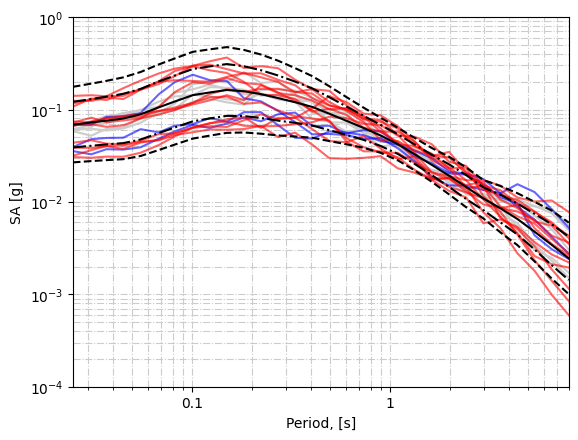

In [43]:
trt_format = {
    "Shallow Default": {"color":"0.8", "alpha":1.0},
    "Subduction Interface": {"color":"r", "alpha":0.6},
    "Subduction Inslab": {"color":"b", "alpha":0.6}
}

periods = [im.period for im in selection_imts if im.name == "SA"]
sas = [im.string for im in selection_imts if im.name == "SA"]
sa_dists = gcim_stats.loc[sas, :]
fig, ax = plt.subplots()

for ii, c in enumerate(sims.columns):
    trt = site_rup_ctxs[ii].trt
    sa_sim = sims.loc[sas, c]
    if trt != "Shallow Default":
        alpha = 0.6
    else:
        alpha = 1.0
    ax.loglog(periods, sa_sim, **trt_format[trt])

ax.loglog(periods, sa_dists["p5"], color="k", ls="--")
ax.loglog(periods, sa_dists["p16"], color="k", ls="-.")
ax.loglog(periods, sa_dists["p50"], color="k")
ax.loglog(periods, sa_dists["p84"], color="k", ls="-.")
ax.loglog(periods, sa_dists["p95"], color="k", ls="--")

formatter = ticker.FuncFormatter(custom_log_formatter)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlim(0.025, 8)
ax.set_ylim(1e-4, 1)

ax.grid(True, which="both", ls="-.", color="0.8")
ax.minorticks_on()
ax.tick_params(axis='y', which='minor', left=False)
ax.set_xlabel("Period, [s]")
ax.set_ylabel("SA [g]")

In [ ]:
gcim_dists

In [ ]:
## Simulation of IMTs for a given M-R-TRT
# # sample the disaggreation data to get a M-R-TRT values
# MRT_sample = disagg_dst.sample(1, weights=disagg_dst["P(m|X>x)"])
# trt = MRT_sample["TRT"].values[0]

# # create the site_rup context for the sampled M-R-TRT
# site_params = sites.loc[site_id,:].to_dict()
# ctx_builder = ESHM20SiteRupCtxBuilder(site_params, average_depths, assumed_rake)

# # initialize the AvgSA GMM with logic tree parameters
# gmm = GMM_MAP[trt][cond_imt.name]


# # calculate the expected ground motion for the sampled M-R-TRT
# mean = np.array([[0.0]])
# sig = np.zeros_like(mean)
# tau = np.zeros_like(mean)
# phi = np.zeros_like(mean)
# gmm.compute(ctx, [], mean, sig, tau, phi)

# # compare the expected to the disaggreagtion level and back-calculate epsilon
# eps = (np.log(imtl) - mean[0,0]) / sig[0,0]

# # calculate the conditional mean and sigma for the sampled M-R-TRT for all imts
# trt_gmms = GMM_MAP[trt]
# mu_cond = []
# sig_cond = []

# rho_mat = corr_model_map[trt]
# for imt in selection_imts:
#     gmm = trt_gmms[imt.name]
#     m = np.array([[0.0]])
#     s = np.zeros_like(m)
#     t = np.zeros_like(m)
#     p = np.zeros_like(mean)
#     gmm.compute(ctx, [imt], m, s, t, p)
    
#     rho = rho_mat.loc[imt.string, cond_imt.string]
#     mu_cond.append(m[0,0] + s[0,0] * rho * eps)
#     sig_cond.append(s[0,0] * np.sqrt(1 - rho ** 2))

# mu_cond = np.array(mu_cond).reshape(-1, 1)
# sig_cond = np.array(sig_cond).reshape(-1, 1)

# generate a random correlated vector
# rng = np.random.default_rng(seed=1)
# u = rng.standard_normal(len(selection_imts)).reshape(-1, 1)
# cond_rho_mat = conditional_correlation_matrix(rho_mat, cond_imt.string)
# L = np.linalg.cholesky(cond_rho_mat)
# v = L @ u

# # create a realisation of the the imt values for this M-R-TRT sample
# sim_imtls = mu_cond + sig_cond * v

In [ ]:
## Record Selection - Choose a GM that matches the simulated imts